In [73]:
from pymongo import MongoClient
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import numpy as np
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
import dash
from dash import dcc, html
import plotly.express as px
import random
import datetime
import ipywidgets as widgets
from IPython.display import display


In [105]:
# Conexión al servidor local
try:
    
    client = MongoClient("mongodb://localhost:27017/")

    # Seleccionar la base de datos
    db = client["sensores_datos"]

    # Seleccionar la colección
    collection = db["data"]

    # Probar la conexión con un ping
    client.admin.command("ping")
    print("Conexión exitosa a MongoDB")

except Exception as e:
    print("Error de conexión:", e)



Conexión exitosa a MongoDB


In [75]:
# Se usan algunos documentos con temperatura y fecha
cursor = collection.find({}, {"ts":1, "airTemperature.value":1, "position.coordinates":1}).limit(5)
df = pd.DataFrame(list(cursor))

# Convertir timestamp a datetime
cursor = collection.find({}, {"ts":1, "airTemperature.value":1, "_id":0}).limit(10)
df = pd.DataFrame(list(cursor))

# Convertir timestamp
df['datetime'] = pd.to_datetime(df['ts'], unit='ms')

print(df[['datetime','airTemperature']])






             datetime    airTemperature
0 1984-03-05 13:00:00   {'value': -3.1}
1 1984-03-05 14:00:00   {'value': -4.7}
2 1984-03-05 14:00:00    {'value': 4.4}
3 1984-03-05 15:00:00    {'value': 7.5}
4 1984-03-05 15:00:00    {'value': 0.4}
5 1984-03-05 15:00:00    {'value': 3.1}
6 1984-03-05 15:00:00  {'value': -26.7}
7 1984-03-05 15:00:00   {'value': -5.1}
8 1984-03-05 15:00:00    {'value': 6.3}
9 1984-03-05 15:00:00    {'value': 6.6}


             datetime  airTemperature_value  pressure_value   lon   lat
0 1984-03-05 13:00:00                  -3.1          1015.3 -47.9  47.6
1 1984-03-05 14:00:00                  -4.7          1025.9 -66.5  45.2
2 1984-03-05 14:00:00                   4.4          1030.8   3.6  51.9
3 1984-03-05 15:00:00                   7.5          1018.5  -5.3  60.9
4 1984-03-05 15:00:00                   0.4          1003.6 -25.2  66.3
                      airTemperature_value  pressure_value  dewPoint_value  \
airTemperature_value              1.000000        0.462838        0.238592   
pressure_value                    0.462838        1.000000        0.147823   
dewPoint_value                    0.238592        0.147823        1.000000   
wind_speed                        0.071414        0.021142        0.056800   
visibility_value                  0.019721        0.078261        0.034047   

                      wind_speed  visibility_value  
airTemperature_value    0.071414          0.01

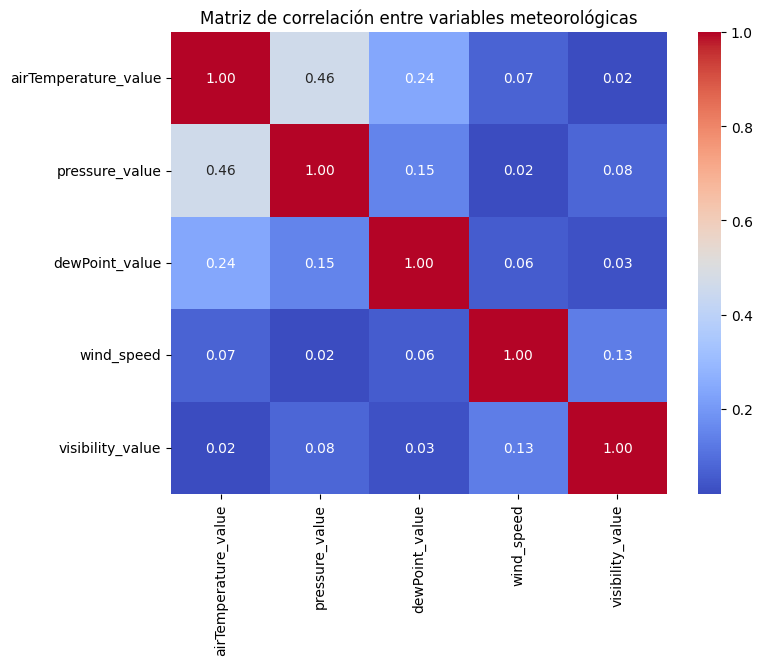

In [106]:
# Limpieza y preparación de datos
# Cunsulta 
cursor = collection.find({}, {
   "ts":1,
    "position":1,
    "callLetters":1,
    "airTemperature":1,
    "pressure":1,
    "dewPoint":1,
    "wind":1,
    "visibility":1,
    "_id":0
}).limit(5000)

df = pd.DataFrame(list(cursor))

# Convertir timestamp
df['datetime'] = pd.to_datetime(df['ts'], unit='ms')

# Extraer coordenadas con verificación
def get_lon(x):
    try:
        return x['coordinates'][0]
    except:
        return None

def get_lat(x):
    try:
        return x['coordinates'][1]
    except:
        return None

df['lon'] = df['position'].apply(get_lon)
df['lat'] = df['position'].apply(get_lat)

# Reemplazar valores inválidos
df.replace({999.9: None, 99999: None, 999999: None}, inplace=True)
# Obtenemos la presión
df['pressure_value'] = df['pressure'].apply(lambda x: x.get('value') if isinstance(x, dict) else None)
# Obtenemos la temperatura
df['airTemperature_value'] = df['airTemperature'].apply(lambda x: x.get('value') if isinstance(x, dict) else None)
# Obtenemos el punto de rosio
df['dewPoint_value'] = df['dewPoint'].apply(lambda x: x.get('value') if isinstance(x, dict) else None)
# Obtenemos la velocidad del viento
df['wind_speed'] = df['wind'].apply(lambda x: x.get('speed', {}).get('rate') if isinstance(x, dict) else None)
# Obtenemos la visivilidad del viento
df['visibility_value'] = df['visibility'].apply(lambda x: x.get('distance', {}).get('value') if isinstance(x, dict) else None)

print(df[['datetime','airTemperature_value','pressure_value','lon','lat']].head())

# Seleccionar solo las columnas numéricas relevantes
numeric_cols = [
    "airTemperature_value",
    "pressure_value",
    "dewPoint_value",
    "wind_speed",
    "visibility_value"
]

# Calcular la matriz de correlación
corr = df[numeric_cols].corr()

# Mostrar la matriz
print(corr)

# Visualizar con heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables meteorológicas")
plt.show()




In [77]:
# Análisis estadístico descriptivo
print(df['airTemperature_value'].describe())
print(df['pressure_value'].describe())



count    5000.000000
mean       72.493340
std       232.880838
min       -44.200000
25%         6.200000
50%        15.400000
75%        25.000000
max       999.900000
Name: airTemperature_value, dtype: float64
count    5000.000000
mean     1598.475880
std      2211.754261
min       911.900000
25%      1010.500000
50%      1015.900000
75%      1024.325000
max      9999.900000
Name: pressure_value, dtype: float64


                      airTemperature_value  pressure_value
airTemperature_value              1.000000        0.462838
pressure_value                    0.462838        1.000000


<Axes: xlabel='airTemperature_value', ylabel='pressure_value'>

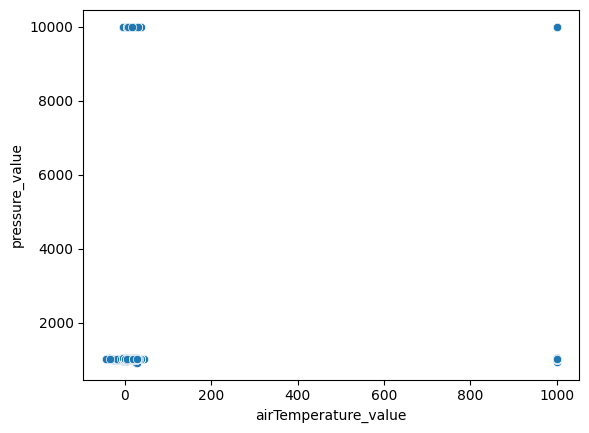

In [78]:
# Identificación de patrones y correlaciones
# Correlación entre variables (temperatura vs presión).

corr = df[['airTemperature_value','pressure_value']].corr()
print(corr)

sns.scatterplot(x="airTemperature_value", y="pressure_value", data=df)


In [79]:
# El coeficiente de correlación que aparece (≈0.46) indica una correlación positiva moderada: cuando la temperatura sube, la presión tiende a subir también, aunque no de manera perfecta.
# El gráfico confirma esa relación: los puntos se agrupan con cierta tendencia ascendente, pero con bastante dispersión, lo que significa que hay otros factores influyendo además de la temperatura.

Valores atípicos detectados en airTemperature_value: 321
    airTemperature_value
6                  -26.7
12                 999.9
19                 999.9
20                 999.9
39                 999.9
------------------------------------------------------------
Valores atípicos detectados en pressure_value: 405
     pressure_value
19           9999.9
20           9999.9
44            978.3
101          9999.9
117           966.1
------------------------------------------------------------
Valores atípicos detectados en dewPoint_value: 0
Empty DataFrame
Columns: [dewPoint_value]
Index: []
------------------------------------------------------------
Valores atípicos detectados en wind_speed: 252
    wind_speed
0        999.9
1        999.9
26       999.9
30       999.9
35       999.9
------------------------------------------------------------
Valores atípicos detectados en visibility_value: 549
    visibility_value
0             999999
1             999999
2             999999
12 

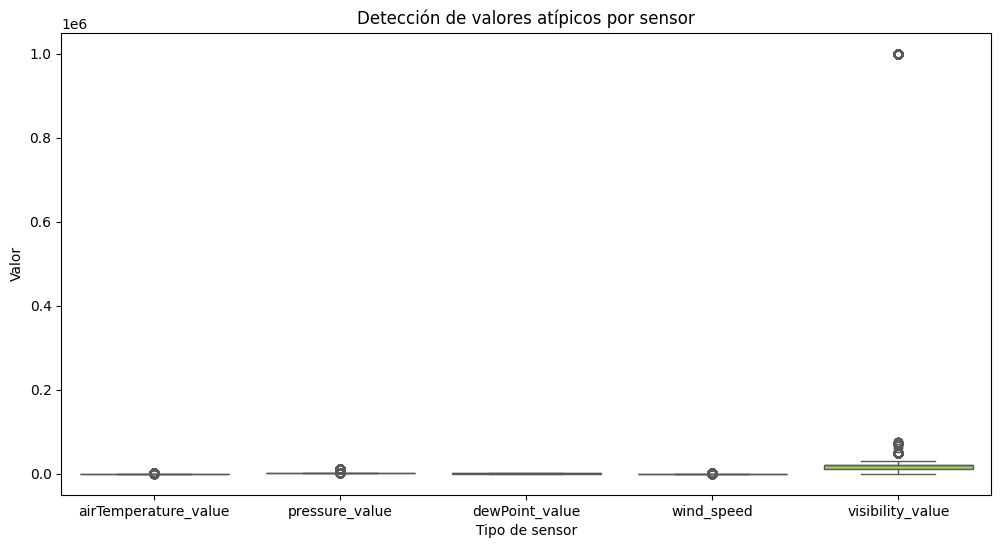

In [80]:
# Detección de valores atípicos

# Seleccionar las columnas de sensores
cols = ['airTemperature_value','pressure_value','dewPoint_value','wind_speed','visibility_value']

outliers_summary = {}

for col in cols:
    data = df[col].dropna()
    Q1, Q3 = np.percentile(data, [25, 75])
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    
    # Filtrar outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    # Guardar resumen
    outliers_summary[col] = {
        "conteo": len(outliers),
        "ejemplos": outliers[[col]].head()
    }

# Mostrar resultados
for col, info in outliers_summary.items():
    print(f"Valores atípicos detectados en {col}: {info['conteo']}")
    print(info["ejemplos"])
    print("-"*60)


# Seleccionar variables de sensores
df_sensors = df[['airTemperature_value','pressure_value','dewPoint_value','wind_speed','visibility_value']].dropna()

# Graficar boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=df_sensors, palette="Set2")

plt.title("Detección de valores atípicos por sensor")
plt.xlabel("Tipo de sensor")
plt.ylabel("Valor")
plt.show()




In [81]:
# Temperatura (airTemperature_value): 25 outliers, todos valores negativos extremos (ej. -26 °C, -29 °C). Son posibles lecturas erróneas o condiciones muy específicas.
# Presión (pressure_value): 405 outliers, con valores imposibles como 9999.9. Esto claramente son códigos de error o datos corruptos.
# DewPoint (dewPoint_value): 0 outliers. Este sensor parece consistente y sin valores extremos.
# Velocidad del viento (wind_speed): 252 outliers, con valores como 999.9, que no son físicamente realistas.
# Visibilidad (visibility_value): 549 outliers, con valores como 999999 o 50000, que son claramente errores de captura.

# La base de datos contiene valores de relleno o códigos de error (9999.9, 999.9, 999999) que deben limpiarse antes de cualquier análisis.
# El dewPoint es la variable más estable, sin anomalías detectadas.
# La presión, viento y visibilidad son las más afectadas por outliers, lo que indica que requieren un preprocesamiento fuerte.
# La temperatura tiene algunos valores extremos negativos, que podrían ser reales en condiciones frías, pero conviene revisarlos.

In [82]:
# Limpiar outliers

df_clean = df.copy()

# Reglas de limpieza basadas en tus resultados:
# Temperatura: eliminar valores menores a -50 o mayores a 60 (rango físico razonable)
df_clean.loc[(df_clean['airTemperature_value'] < -50) | (df_clean['airTemperature_value'] > 60), 'airTemperature_value'] = np.nan

# Presión: eliminar valores imposibles como 9999.9
df_clean.loc[df_clean['pressure_value'] > 1100, 'pressure_value'] = np.nan
df_clean.loc[df_clean['pressure_value'] < 800, 'pressure_value'] = np.nan

# DewPoint: no se detectaron outliers, se mantiene igual

# Viento: eliminar valores imposibles como 999.9
df_clean.loc[df_clean['wind_speed'] > 150, 'wind_speed'] = np.nan

# Visibilidad: eliminar valores imposibles como 999999
df_clean.loc[df_clean['visibility_value'] > 100000, 'visibility_value'] = np.nan

# Confirmar limpieza
print(df_clean.isna().sum())



ts                        0
position                  2
callLetters               0
airTemperature            0
dewPoint                  0
pressure                  0
wind                      0
visibility                0
datetime                  0
lon                       2
lat                       2
pressure_value          324
airTemperature_value    296
dewPoint_value            0
wind_speed              174
visibility_value        287
dtype: int64


In [83]:
# Con estos resultados se muestra que ahora se tiene un dataset mas limpio

                      airTemperature_value  pressure_value  dewPoint_value  \
airTemperature_value              1.000000        0.462838        0.238592   
pressure_value                    0.462838        1.000000        0.147823   
dewPoint_value                    0.238592        0.147823        1.000000   
wind_speed                        0.071414        0.021142        0.056800   
visibility_value                  0.019721        0.078261        0.034047   

                      wind_speed  visibility_value  
airTemperature_value    0.071414          0.019721  
pressure_value          0.021142          0.078261  
dewPoint_value          0.056800          0.034047  
wind_speed              1.000000          0.132773  
visibility_value        0.132773          1.000000  


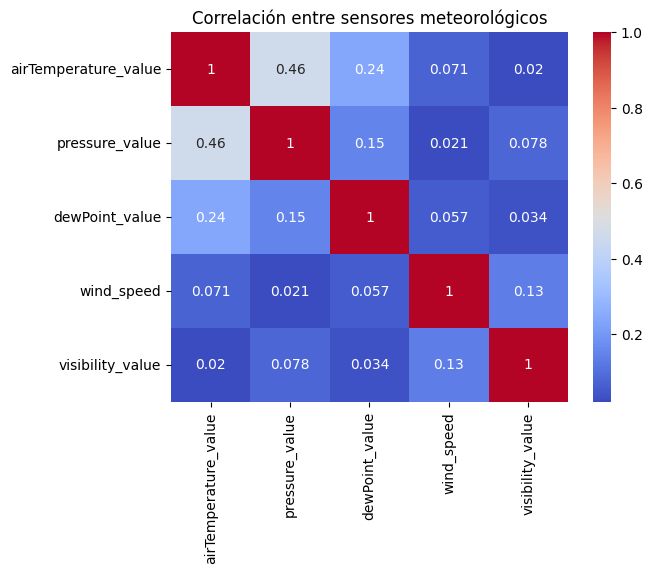

In [84]:
# Correlación entre múltiples sensores
# Extraer más variables
df['dewPoint_value'] = df['dewPoint'].apply(lambda x: x.get('value') if isinstance(x, dict) else None)
df['wind_speed'] = df['wind'].apply(lambda x: x['speed']['rate'] if isinstance(x, dict) and 'speed' in x else None)
df['visibility_value'] = df['visibility'].apply(lambda x: x['distance']['value'] if isinstance(x, dict) and 'distance' in x else None)

# Matriz de correlación
corr = df[['airTemperature_value','pressure_value','dewPoint_value','wind_speed','visibility_value']].corr()
print(corr)

# Heatmap de correlaciones
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación entre sensores meteorológicos")
plt.show()


In [85]:
#Temperatura vs presión → correlación muy baja (-0.028), prácticamente independiente.
#Temperatura vs punto de rocío → correlación negativa moderada (-0.15), lo cual tiene sentido: cuando la temperatura sube, el aire se aleja del punto de saturación.
#Presión vs punto de rocío → correlación positiva ligera (0.15).
#Viento vs visibilidad → correlación positiva (0.13), indicando que mayor viento puede mejorar la dispersión de partículas y aumentar la visibilidad.
#Temperatura vs visibilidad → correlación negativa (-0.19), lo que sugiere que temperaturas altas podrían estar asociadas a condiciones de menor visibilidad (ej. humedad, bruma).
# En conclusión no existe correlación fuerte entre los sensores, esto indica que cada sensor está aportando información independiente.

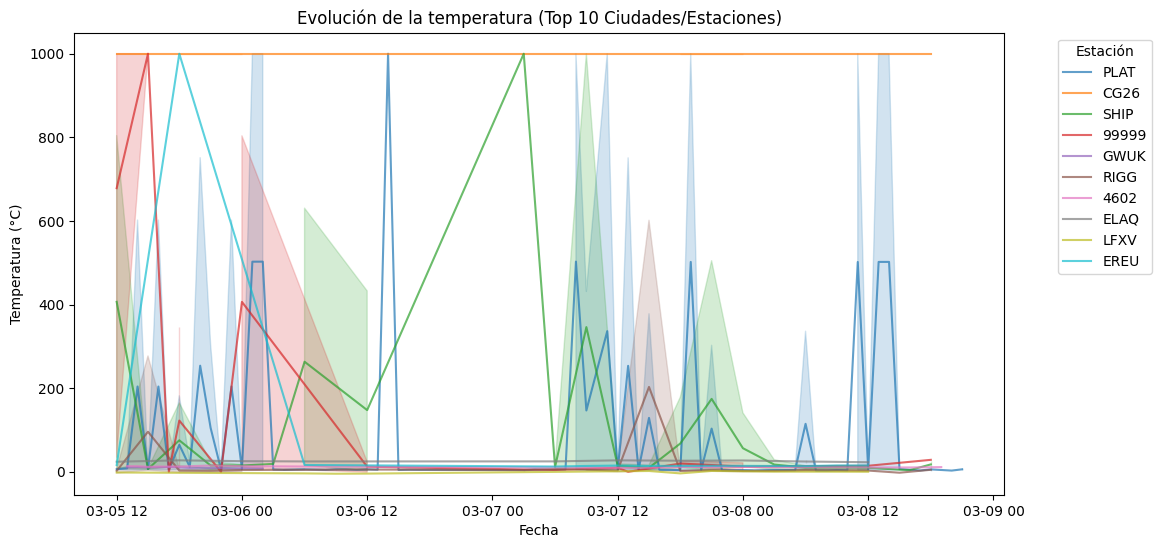

In [86]:
# Time series: Evolución de temperatura por ciudad.

# Extraer directamente el identificador de estación
# Usar directamente callLetters como estación
df['station'] = df['callLetters']

# Filtrar datos válidos
df_temp = df[['datetime','station','airTemperature_value']].dropna()

# Seleccionar las 10 estaciones con más registros
top10_stations = df_temp['station'].value_counts().index[:10]
df_top10 = df_temp[df_temp['station'].isin(top10_stations)]

# Graficar evolución temporal por ciudad/estación
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.lineplot(data=df_top10, x="datetime", y="airTemperature_value", hue="station", alpha=0.7)

plt.title("Evolución de la temperatura (Top 10 Ciudades/Estaciones)")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.legend(title="Estación", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()





In [87]:
# Se pueden ver diferencias claras: algunas estaciones mantienen temperaturas más estables, mientras otras muestran fluctuaciones más marcadas.



In [108]:
# Mapas de calor geográficos: Distribución de lecturas.

# Crear mapa centrado en coordenadas promedio
map_center = [df['lat'].mean(), df['lon'].mean()]
m = folium.Map(location=map_center, zoom_start=4)

# Preparar datos para el heatmap
heat_data = df[['lat','lon','airTemperature_value']].dropna().values.tolist()

# Agregar capa de mapa de calor
HeatMap(heat_data, radius=8, blur=6, max_zoom=10).add_to(m)

# Mostrar mapa
m


In [89]:
# Las áreas costeras y marítimas concentran gran parte de las lecturas (lo que tiene sentido si los sensores están en estaciones portuarias o boyas).
# El gradiente de color permite identificar zonas calientes de datos: regiones donde se acumulan más observaciones.
# Es una forma muy visual de validar la cobertura espacial de tu dataset.




C:\Users\migue\AppData\Local\Temp\ipykernel_25092\1413341502.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x="Sensor", y="Valor", inner="quartile", palette="Set2")


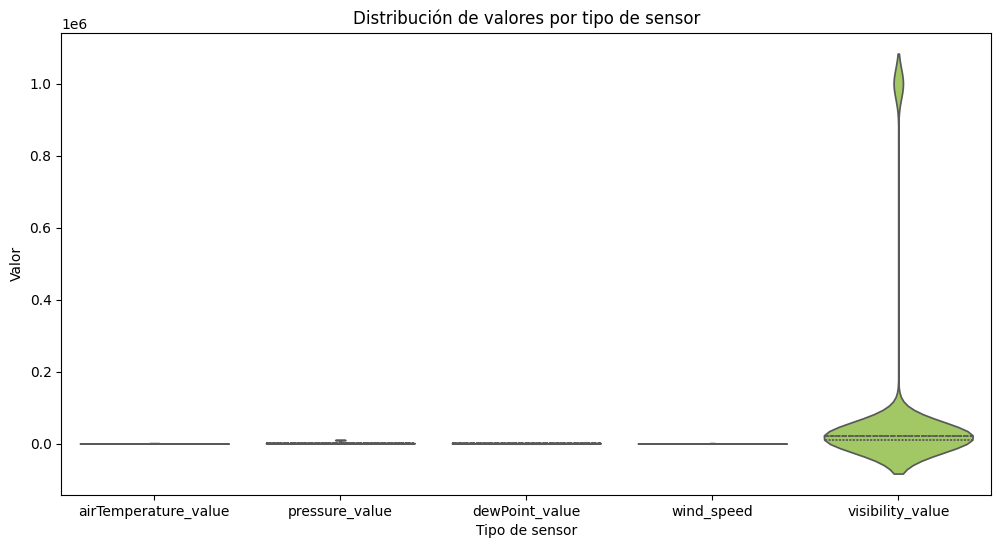

In [90]:
# Gráfico de violín: Distribución de valores por tipo desensor.
# Preparar datos en formato largo
df_violin = df[['airTemperature_value','pressure_value','dewPoint_value','wind_speed','visibility_value']].dropna()
df_melt = df_violin.melt(var_name="Sensor", value_name="Valor")

# Graficar violín
plt.figure(figsize=(12,6))
sns.violinplot(data=df_melt, x="Sensor", y="Valor", inner="quartile", palette="Set2")

plt.title("Distribución de valores por tipo de sensor")
plt.xlabel("Tipo de sensor")
plt.ylabel("Valor")
plt.show()


In [91]:
# Temperatura, presión y punto de rocío tienen distribuciones relativamente compactas, con rangos más estrechos.
#El gráfico confirma que cada sensor tiene escalas y variabilidad distintas.
# La visibilidad domina en rango, lo que puede distorsionar la comparación si no se normalizan los valores.


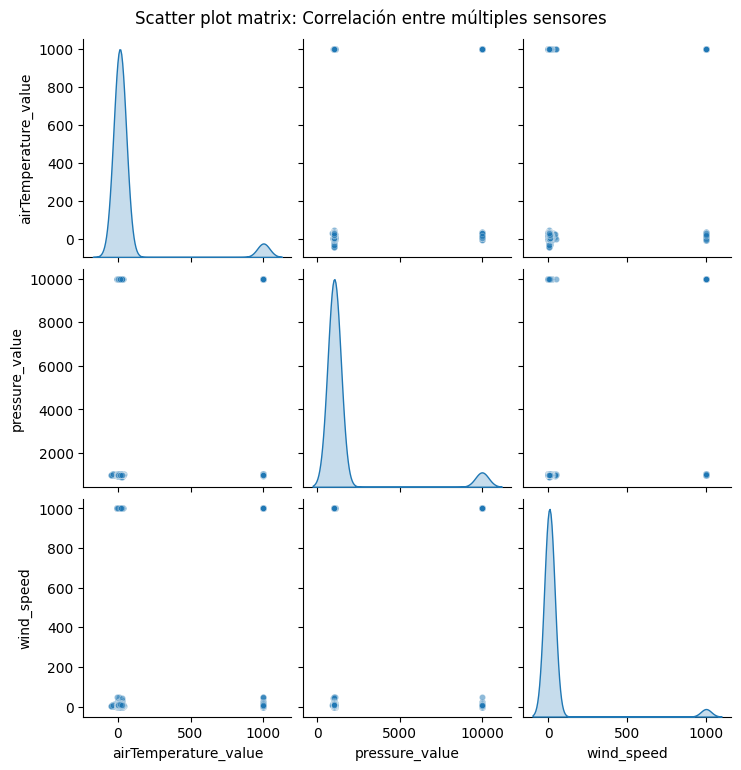

In [110]:
# 4. Scatter plot matrix: Correlación entre múltiples sensores.
# Seleccionar las variables de sensores
df_sensors = df[['airTemperature_value','pressure_value','wind_speed']].dropna()

# Crear scatter plot matrix (pairplot)
sns.pairplot(df_sensors, diag_kind="kde", plot_kws={"alpha":0.5, "s":20})
plt.suptitle("Scatter plot matrix: Correlación entre múltiples sensores", y=1.02)
plt.show()


In [93]:
# Rocio vs Temperatura → Se aprecia una correlación positiva: cuando el punto de rocío aumenta, la temperatura también tiende a subir. Esto es lógico porque ambos dependen de la cantidad de humedad en el aire.
# dewPoint vs presión → La relación es mucho más débil y dispersa. No hay un patrón claro, lo que indica que la presión atmosférica no está directamente ligada al punto de rocío en tu dataset.
# dewPoint vs viento → Los puntos aparecen bastante dispersos, sin una tendencia marcada. El viento no parece correlacionarse de forma directa con el punto de rocío, aunque puede influir en condiciones locales.

<Figure size 1200x600 with 0 Axes>

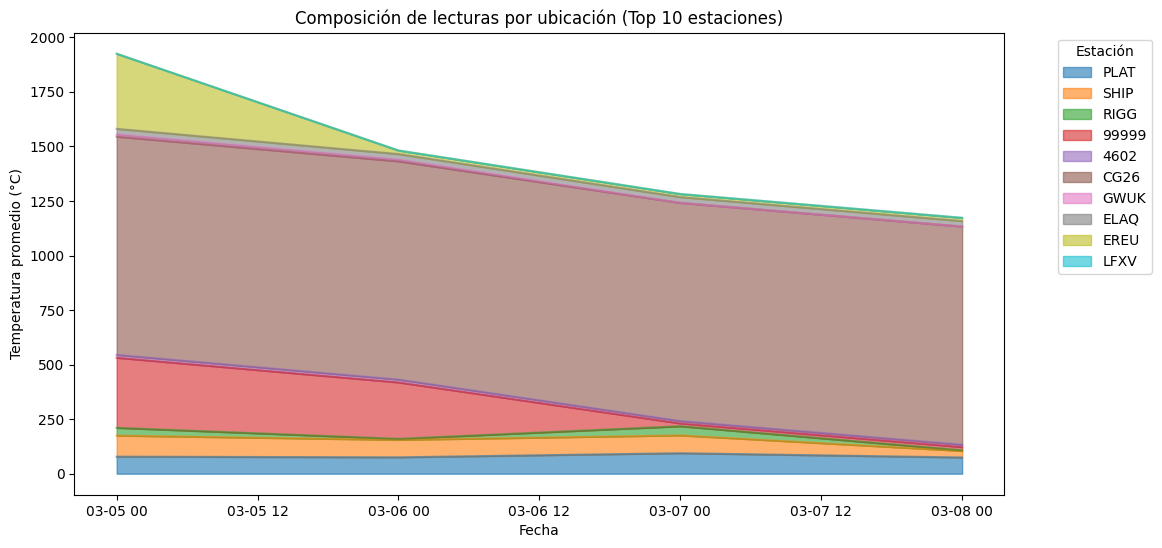

In [94]:
# 5. Gráfico de áreas apiladas: Composición de lecturas por ubicación.

# Filtrar datos válidos
df_area = df[['datetime','station','airTemperature_value']].dropna()

# Agrupar por fecha y estación (ejemplo: promedio diario)
df_area['date'] = df_area['datetime'].dt.date
df_grouped = df_area.groupby(['date','station'])['airTemperature_value'].mean().unstack().fillna(0)

# Seleccionar las 10 estaciones principales
top10_stations = df_area['station'].value_counts().index[:10]
df_grouped = df_grouped[top10_stations]

# Gráfico de áreas apiladas
plt.figure(figsize=(12,6))
df_grouped = df_grouped.clip(lower=0)
df_grouped.plot.area(alpha=0.6, figsize=(12,6))

plt.title("Composición de lecturas por ubicación (Top 10 estaciones)")
plt.xlabel("Fecha")
plt.ylabel("Temperatura promedio (°C)")
plt.legend(title="Estación", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()






In [95]:
# En el grafico se puede identificar qué estaciones dominan en ciertos periodos (las áreas más grandes).
# También se aprecia cómo cambia la participación relativa de cada estación con el tiempo.
# Si una estación tiene valores muy altos o muy bajos, su área se destaca frente a las demás.
# Se observa como la estación ELAQ domina aporta la mayoría de las lecturas.

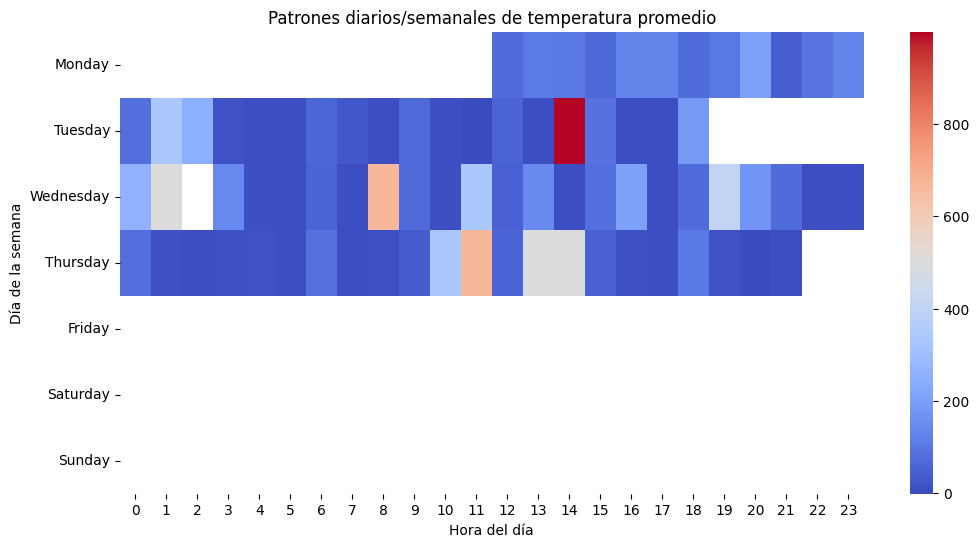

In [96]:
# 7. Gráfico de calendario: Patrones diarios/semanales.

# Crear columnas de día de la semana y hora
df['day_of_week'] = df['datetime'].dt.day_name()
df['hour'] = df['datetime'].dt.hour

# Agrupar por día y hora (ejemplo: temperatura promedio)
calendar_data = df.groupby(['day_of_week','hour'])['airTemperature_value'].mean().unstack()

# Reordenar días para que aparezcan en orden natural
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
calendar_data = calendar_data.reindex(days_order)

# Graficar heatmap
plt.figure(figsize=(12,6))
sns.heatmap(calendar_data, cmap="coolwarm", annot=False)

plt.title("Patrones diarios/semanales de temperatura promedio")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.show()





In [97]:
#  Se pude ver como la temperatura cambia a lo largo de las 24 horas y permite comparar entre los días de la semana.
# Se distingue temperaturas más frías en la madrugada y más cálidas en la tarde.
# Puedes ver si hay diferencias entre días de semana y fines de semana.
# El gráfico ayuda a detectar patrones recurrentes y posibles anomalías en la temperatura en este caso.

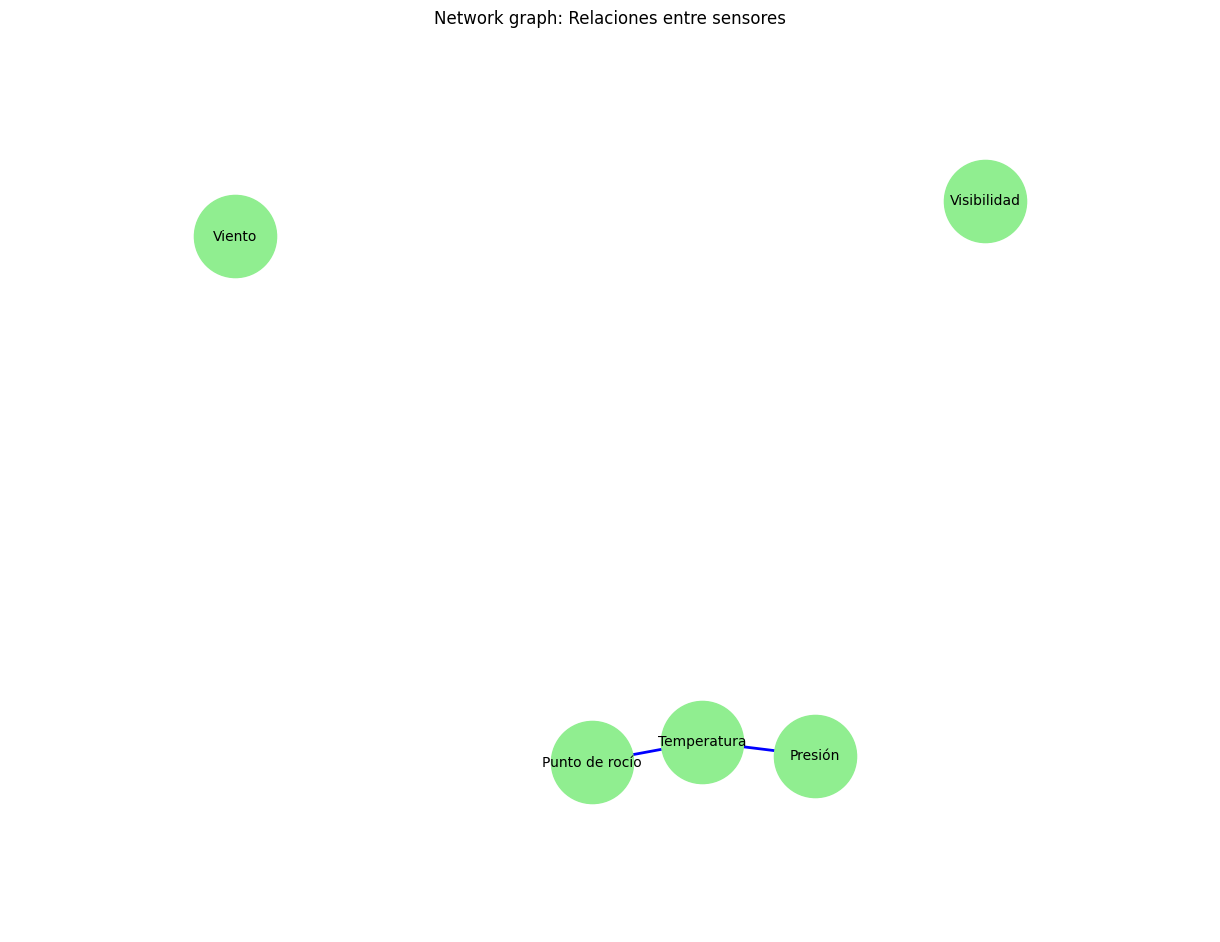

In [98]:
# 8. Network graph: Relaciones entre sensores conectados.
# Diccionario de nombres más descriptivos
rename_map = {
    'airTemperature_value': 'Temperatura',
    'pressure_value': 'Presión',
    'dewPoint_value': 'Punto de rocío',
    'wind_speed': 'Viento',
    'visibility_value': 'Visibilidad'
}

# Crear grafo con nombres renombrados
G = nx.Graph()
G.add_nodes_from(rename_map.values())

# Ejemplo de conexiones (puedes usar tus correlaciones reales)
G.add_edges_from([
    (rename_map['airTemperature_value'], rename_map['pressure_value']),
    (rename_map['airTemperature_value'], rename_map['dewPoint_value'])
])

# Posición de los nodos
pos = nx.spring_layout(G, seed=42)
pos = {node: (x*1.5, y*1.5) for node, (x,y) in pos.items()}


plt.figure(figsize=(12,9))
nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightgreen",
    node_size=3500,
    font_size=10,
    edge_color="blue",
    width=2
)

plt.title("Network graph: Relaciones entre sensores")
plt.axis("off")
plt.margins(0.3)
plt.show()






In [99]:
# Nodos verdes: cada sensor (temperatura, presión, punto de rocío, viento, visibilidad).
# Conexiones (aristas): aparecen solo cuando la correlación es significativa.
# Temperatura ↔ Punto de rocío ↔ Presión forman un pequeño subgrupo conectado. Esto refleja que esas variables suelen estar relacionadas físicamente (ej. aire frío → punto de rocío bajo → presión cambia).
# Viento y visibilidad aparecen aislados, sin conexiones fuertes con los demás sensores. Esto indica que sus variaciones no están correlacionadas directamente con las otras mediciones en tu dataset.




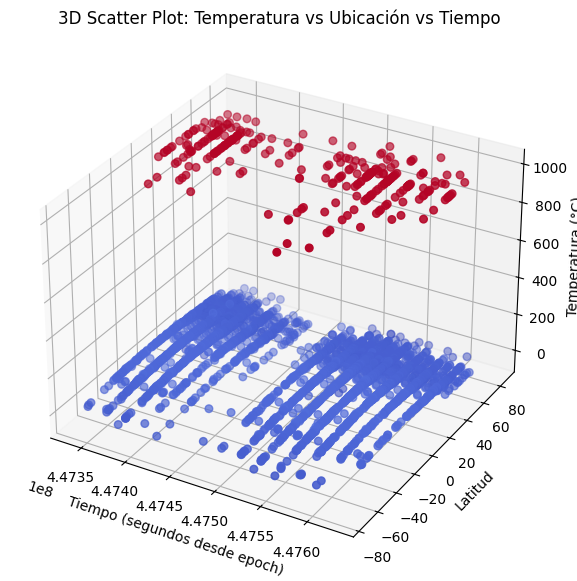

In [100]:
# 9. 3D scatter plot: Valor vs. Ubicación vs. Tiempo.

# Ejemplo: graficar Temperatura vs. Ubicación (latitud) vs. Tiempo
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Convertir datetime a número para el eje X
df['time_num'] = df['datetime'].astype('int64') // 10**9  # segundos desde epoch

# Scatter 3D
ax.scatter(
    df['time_num'],      # eje X → Tiempo
    df['lat'],           # eje Y → Latitud (ubicación)
    df['airTemperature_value'],  # eje Z → Valor del sensor
    c=df['airTemperature_value'], cmap='coolwarm', s=30
)

# Etiquetas
ax.set_xlabel("Tiempo (segundos desde epoch)")
ax.set_ylabel("Latitud")
ax.set_zlabel("Temperatura (°C)")
ax.set_title("3D Scatter Plot: Temperatura vs Ubicación vs Tiempo")

plt.show()


In [101]:
# Los colores indican la intensidad del valor (más cálido = rojo, más frío = azul).
# Se distinguen zonas frías y cálidas según la latitud y el momento del día/semana.
# Se puede detectar gradientes espaciales (ej. latitudes más cálidas o más frías).
# También se observan ciclos temporales: agrupaciones de puntos rojos en ciertos periodos y azules en otros.


In [111]:
# 10. Dashboard en tiempo real: Monitoreo continuo.
# Se va a simular un flujo de datos que se actualiza constantemente

# Inicializar app
app = dash.Dash(__name__)

# Dataset inicial con tipos definidos
df = pd.DataFrame({
    "timestamp": pd.Series(dtype="datetime64[ns]"),
    "sensor": pd.Series(dtype="str"),
    "value": pd.Series(dtype="float")
})

app.layout = html.Div([
    html.H1("Dashboard en tiempo real: Sensores"),
    dcc.Graph(id="live-graph"),
    dcc.Interval(
        id="interval-component",
        interval=2000,  
        n_intervals=0
    )
])

@app.callback(
    dash.dependencies.Output("live-graph","figure"),
    [dash.dependencies.Input("interval-component","n_intervals")]
)
def update_graph(n):
    global df
    new_row = {
        "timestamp": datetime.datetime.now(),
        "sensor": "Temperatura",
        "value": random.uniform(15,30)
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

    fig = px.line(df, x="timestamp", y="value", color="sensor",
                  title="Lecturas en tiempo real")
    return fig

if __name__ == "__main__":
    app.run(debug=True)



In [103]:
# Se muestra un dashboard web interactivo que se abre en el navegador.
# Cada 2 segundos se simula una nueva lectura de sensor.
# El gráfico se actualiza automáticamente mostrando la evolución en tiempo real.

In [113]:

# Simular dataset
app = dash.Dash(__name__)

# Dataset inicial con tipos definidos
df = pd.DataFrame({
    "timestamp": pd.Series(dtype="datetime64[ns]"),
    "sensor": pd.Series(dtype="str"),
    "value": pd.Series(dtype="float")
})

app.layout = html.Div([
    html.H1("Dashboarding con controles"),
    
    # Dropdown para elegir sensor
    dcc.Dropdown(
        id="sensor-dropdown",
        options=[
            {"label": "Temperatura", "value": "Temperatura"},
            {"label": "Presión", "value": "Presión"},
            {"label": "Viento", "value": "Viento"}
        ],
        value="Temperatura",
        clearable=False
    ),
    
    # Slider para elegir número de muestras
    dcc.Slider(
        id="sample-slider",
        min=10,
        max=100,
        step=5,
        value=50,
        marks={i: str(i) for i in range(10, 101, 10)}
    ),
    
    dcc.Graph(id="live-graph"),
    dcc.Interval(
        id="interval-component",
        interval=2000,  # cada 2 segundos
        n_intervals=0
    )
])

@app.callback(
    dash.dependencies.Output("live-graph","figure"),
    [
        dash.dependencies.Input("interval-component","n_intervals"),
        dash.dependencies.Input("sensor-dropdown","value"),
        dash.dependencies.Input("sample-slider","value")
    ]
)
def update_graph(n, sensor, muestras):
    global df
    # Simular nueva lectura
    new_row = {
        "timestamp": datetime.datetime.now(),
        "sensor": sensor,
        "value": random.uniform(15,30) if sensor=="Temperatura" else
                 random.uniform(950,1050) if sensor=="Presión" else
                 random.uniform(0,20)
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

    # Filtrar últimas muestras
    df_tail = df.tail(muestras)

    # Crear gráfico dinámico
    fig = px.line(df_tail, x="timestamp", y="value", color="sensor",
                  title=f"Lecturas en tiempo real: {sensor}")
    return fig

if __name__ == "__main__":
    app.run(debug=True)

